# HAB Strategy Symbol Scan

这个 notebook 会对 `hab_bars.csv` 里的所有品种逐个回测 HAB 策略，并输出每个品种的关键结果指标和资金曲线对比，帮助你判断策略在哪些品种上更有效。

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if repo_root.name == "note":
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from strats.horizontal_accumulation_breakout_v1 import HABConfig, HorizontalAccumulationBreakoutV1

In [10]:
# Scan inputs
hab_bars_path = repo_root / "data" / "cache" / "normalized" / "hab_bars.csv"

# 留空表示全品种；也可以填 ['CU', 'AU', 'IF']
symbols = []

# 留空表示全历史
start_date = None
end_date = None

# 数据质量处理：'clamp' / 'drop' / 'strict'
data_quality_mode = "clamp"

# 排名前后各画多少条资金曲线
top_n = 6
bottom_n = 6

# 排序指标：'total_return_pct' / 'final_equity' / 'avg_r_multiple' / 'win_rate_pct'
sort_by = "total_return_pct"

# 只覆盖你想改的策略参数
config_overrides = {
    "initial_capital": 1_000_000,
    "risk_per_trade": 0.04,
    "portfolio_risk_cap": 0.12,
    "group_risk_cap": 0.06,

    "box_lookback": 7,
    "box_width_atr_mult": 1.5,
    "tol_atr_mult": 0.25,
    "breakout_atr_mult": 0.5,
    "upper_shadow_ratio_max": 0.25,
    "initial_stop_atr_mult": 0.4,

    "structure_fail_bars": 3,
    "time_fail_bars": 5,
    "time_fail_target_r": 0.3,
    "trail_activate_r": 1.0,
    "trail_atr_mult": 2.0,
}

In [11]:
bars = pd.read_csv(hab_bars_path, parse_dates=["date"])
bars = bars.sort_values(["date", "symbol"]).reset_index(drop=True)

if symbols:
    selected_symbols = [symbol.strip().upper() for symbol in symbols]
    bars = bars.loc[bars["symbol"].isin(selected_symbols)].copy()

if start_date is not None:
    bars = bars.loc[bars["date"] >= pd.Timestamp(start_date)].copy()
if end_date is not None:
    bars = bars.loc[bars["date"] <= pd.Timestamp(end_date)].copy()

if bars.empty:
    raise ValueError("No bars left after applying filters.")

ohlc_upper = bars[["open", "close"]].max(axis=1)
ohlc_lower = bars[["open", "close"]].min(axis=1)
invalid_ohlc_mask = (bars["high"] < ohlc_upper) | (bars["low"] > ohlc_lower)
invalid_rows = bars.loc[invalid_ohlc_mask, ["date", "symbol", "open", "high", "low", "close"]].copy()

print(f"rows: {len(bars):,}")
print(f"symbols: {bars['symbol'].nunique():,}")
print(f"date range: {bars['date'].min().date()} -> {bars['date'].max().date()}")
print(f"invalid OHLC rows: {len(invalid_rows):,}")
if not invalid_rows.empty:
    print(invalid_rows['symbol'].value_counts().head(10).to_string())

backtest_bars = bars.copy()
if data_quality_mode == "clamp":
    backtest_bars.loc[invalid_ohlc_mask, "high"] = backtest_bars.loc[invalid_ohlc_mask, ["high", "open", "close"]].max(axis=1)
    backtest_bars.loc[invalid_ohlc_mask, "low"] = backtest_bars.loc[invalid_ohlc_mask, ["low", "open", "close"]].min(axis=1)
elif data_quality_mode == "drop":
    backtest_bars = backtest_bars.loc[~invalid_ohlc_mask].copy()
elif data_quality_mode == "strict":
    pass
else:
    raise ValueError("data_quality_mode must be one of: 'clamp', 'drop', 'strict'")

if backtest_bars.empty:
    raise ValueError("No bars left after data quality handling.")

print(f"rows used in scan: {len(backtest_bars):,}")

rows: 135,638
symbols: 91
date range: 2018-01-02 -> 2025-12-31
invalid OHLC rows: 144
symbol
RS    62
WH    21
BB    21
JR    10
RI     9
ZC     7
PM     6
FB     4
LR     3
WR     1
rows used in scan: 135,638


In [12]:
cfg = HABConfig(**config_overrides)
engine = HorizontalAccumulationBreakoutV1(cfg)

summary_rows = []
equity_curves = {}

for symbol, symbol_bars in backtest_bars.groupby("symbol", sort=True):
    symbol_bars = symbol_bars.sort_values("date").copy()
    result = engine.run(symbol_bars)

    portfolio_daily = result.portfolio_daily.copy()
    if portfolio_daily.empty:
        continue

    portfolio_daily["date"] = pd.to_datetime(portfolio_daily["date"])
    portfolio_daily["equity"] = portfolio_daily["equity"].astype(float)
    equity = portfolio_daily["equity"]
    running_peak = equity.cummax()
    drawdown = equity / running_peak - 1.0

    trades = result.trades.copy()
    if not trades.empty:
        win_rate_pct = float((trades["net_pnl"] > 0).mean() * 100.0)
        avg_net_pnl = float(trades["net_pnl"].mean())
        avg_r_multiple = float(trades["r_multiple"].mean())
    else:
        win_rate_pct = np.nan
        avg_net_pnl = np.nan
        avg_r_multiple = np.nan

    summary_rows.append(
        {
            "symbol": symbol,
            "final_equity": float(equity.iloc[-1]),
            "total_return_pct": float((equity.iloc[-1] / equity.iloc[0] - 1.0) * 100.0),
            "max_drawdown_pct": float(drawdown.min() * 100.0),
            "closed_trades": int(len(trades)),
            "open_positions": int(len(result.open_positions)),
            "cancelled_entries": int(len(result.cancelled_entries)),
            "win_rate_pct": win_rate_pct,
            "avg_net_pnl": avg_net_pnl,
            "avg_r_multiple": avg_r_multiple,
        }
    )
    equity_curves[symbol] = portfolio_daily[["date", "equity"]].copy()

summary_df = pd.DataFrame(summary_rows)
if summary_df.empty:
    raise ValueError("No per-symbol results were produced.")

summary_df = summary_df.sort_values(sort_by, ascending=False).reset_index(drop=True)
summary_df

,symbol,final_equity,total_return_pct,max_drawdown_pct,closed_trades,open_positions,cancelled_entries,win_rate_pct,avg_net_pnl,avg_r_multiple
0,BB,1.351183e+06,35.118295,-6.258141,3,0,0,66.666667,117060.984597,2.987711
1,FG,1.142672e+06,14.267163,-0.549002,1,0,0,100.000000,142671.633108,4.112996
2,CF,1.139151e+06,13.915091,-1.156557,1,0,0,100.000000,139150.914059,3.450850
3,I,1.135339e+06,13.533878,-3.079795,1,0,0,100.000000,135338.783828,3.277523
4,AU,1.104546e+06,10.454604,-3.104154,3,0,0,66.666667,34848.680033,0.654863
...,...,...,...,...,...,...,...,...,...,...
86,UR,9.620013e+05,-3.799868,-5.929161,1,0,0,0.000000,-37998.680025,-1.007156
87,M,9.337490e+05,-6.625105,-6.647976,2,0,0,0.000000,-33125.523416,-0.818027
88,RI,9.260224e+05,-7.397762,-13.763740,5,0,0,20.000000,-14795.524852,-0.487381
89,WR,8.733000e+05,-12.670000,-13.486257,4,0,0,0.000000,-31675.000000,-1.002155


In [13]:
display_cols = [
    "symbol",
    "final_equity",
    "total_return_pct",
    "max_drawdown_pct",
    "closed_trades",
    "open_positions",
    "cancelled_entries",
    "win_rate_pct",
    "avg_net_pnl",
    "avg_r_multiple",
]

summary_df[display_cols].head(20)

,symbol,final_equity,total_return_pct,max_drawdown_pct,closed_trades,open_positions,cancelled_entries,win_rate_pct,avg_net_pnl,avg_r_multiple
0,BB,1.351183e+06,35.118295,-6.258141,3,0,0,66.666667,117060.984597,2.987711
1,FG,1.142672e+06,14.267163,-0.549002,1,0,0,100.000000,142671.633108,4.112996
2,CF,1.139151e+06,13.915091,-1.156557,1,0,0,100.000000,139150.914059,3.450850
3,I,1.135339e+06,13.533878,-3.079795,1,0,0,100.000000,135338.783828,3.277523
4,AU,1.104546e+06,10.454604,-3.104154,3,0,0,66.666667,34848.680033,0.654863
5,AL,1.103749e+06,10.374940,-1.962144,1,0,0,100.000000,103749.400047,2.592540
6,PM,1.092285e+06,9.228509,-8.559482,4,0,0,50.000000,23071.272213,0.540565
7,FU,1.066693e+06,6.669260,-6.874682,2,0,0,50.000000,33346.300656,0.851902
8,PB,1.062728e+06,6.272785,-2.798833,2,0,0,100.000000,31363.926563,0.832815
9,HC,1.032500e+06,3.250000,-1.970906,2,0,0,50.000000,16250.000000,0.418248


In [14]:
print("Top symbols")
display(summary_df[display_cols].head(top_n))

print("Bottom symbols")
display(summary_df[display_cols].tail(bottom_n))

Top symbols


,symbol,final_equity,total_return_pct,max_drawdown_pct,closed_trades,open_positions,cancelled_entries,win_rate_pct,avg_net_pnl,avg_r_multiple
0,BB,1.351183e+06,35.118295,-6.258141,3,0,0,66.666667,117060.984597,2.987711
1,FG,1.142672e+06,14.267163,-0.549002,1,0,0,100.000000,142671.633108,4.112996
2,CF,1.139151e+06,13.915091,-1.156557,1,0,0,100.000000,139150.914059,3.450850
3,I,1.135339e+06,13.533878,-3.079795,1,0,0,100.000000,135338.783828,3.277523
4,AU,1.104546e+06,10.454604,-3.104154,3,0,0,66.666667,34848.680033,0.654863
5,AL,1.103749e+06,10.374940,-1.962144,1,0,0,100.000000,103749.400047,2.592540


Bottom symbols


,symbol,final_equity,total_return_pct,max_drawdown_pct,closed_trades,open_positions,cancelled_entries,win_rate_pct,avg_net_pnl,avg_r_multiple
85,CJ,964853.969579,-3.514603,-4.038553,1,0,0,0.0,-35146.030421,-1.006011
86,UR,962001.319975,-3.799868,-5.929161,1,0,0,0.0,-37998.680025,-1.007156
87,M,933748.953168,-6.625105,-6.647976,2,0,0,0.0,-33125.523416,-0.818027
88,RI,926022.375741,-7.397762,-13.763740,5,0,0,20.0,-14795.524852,-0.487381
89,WR,873300.000000,-12.670000,-13.486257,4,0,0,0.0,-31675.000000,-1.002155
90,TF,600400.000000,-39.960000,-39.960000,2,0,0,0.0,-199800.000000,-1.471004


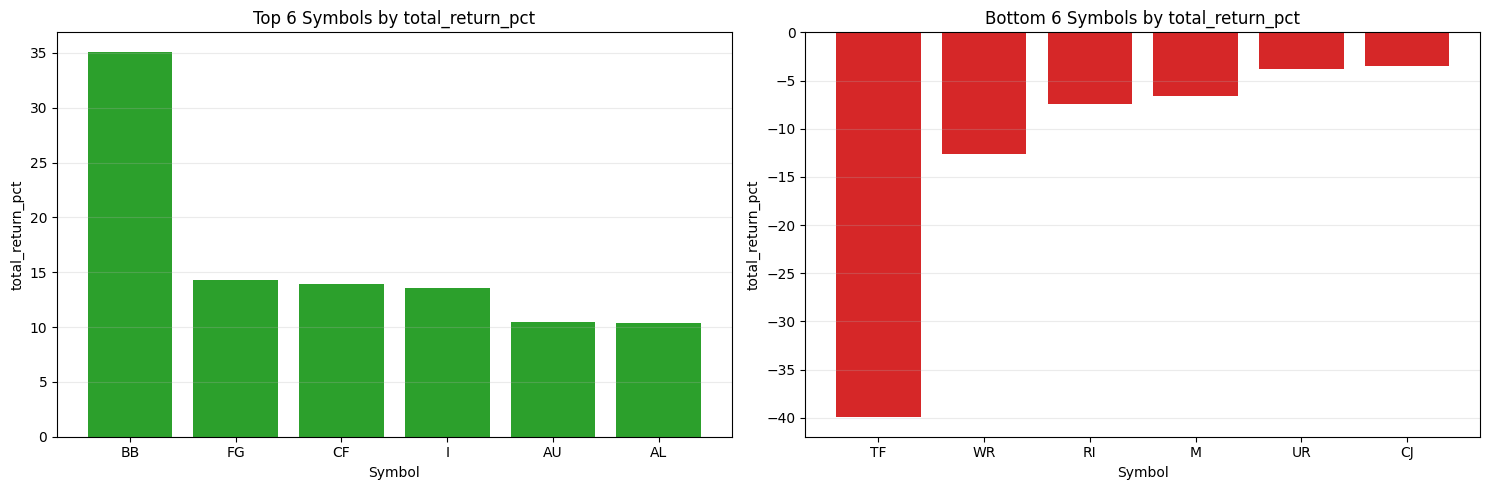

In [15]:
top_df = summary_df.head(top_n).copy()
bottom_df = summary_df.tail(bottom_n).copy().sort_values(sort_by, ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(top_df["symbol"], top_df[sort_by], color="tab:green")
axes[0].set_title(f"Top {top_n} Symbols by {sort_by}")
axes[0].set_xlabel("Symbol")
axes[0].set_ylabel(sort_by)
axes[0].grid(True, axis="y", alpha=0.25)

axes[1].bar(bottom_df["symbol"], bottom_df[sort_by], color="tab:red")
axes[1].set_title(f"Bottom {bottom_n} Symbols by {sort_by}")
axes[1].set_xlabel("Symbol")
axes[1].set_ylabel(sort_by)
axes[1].grid(True, axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

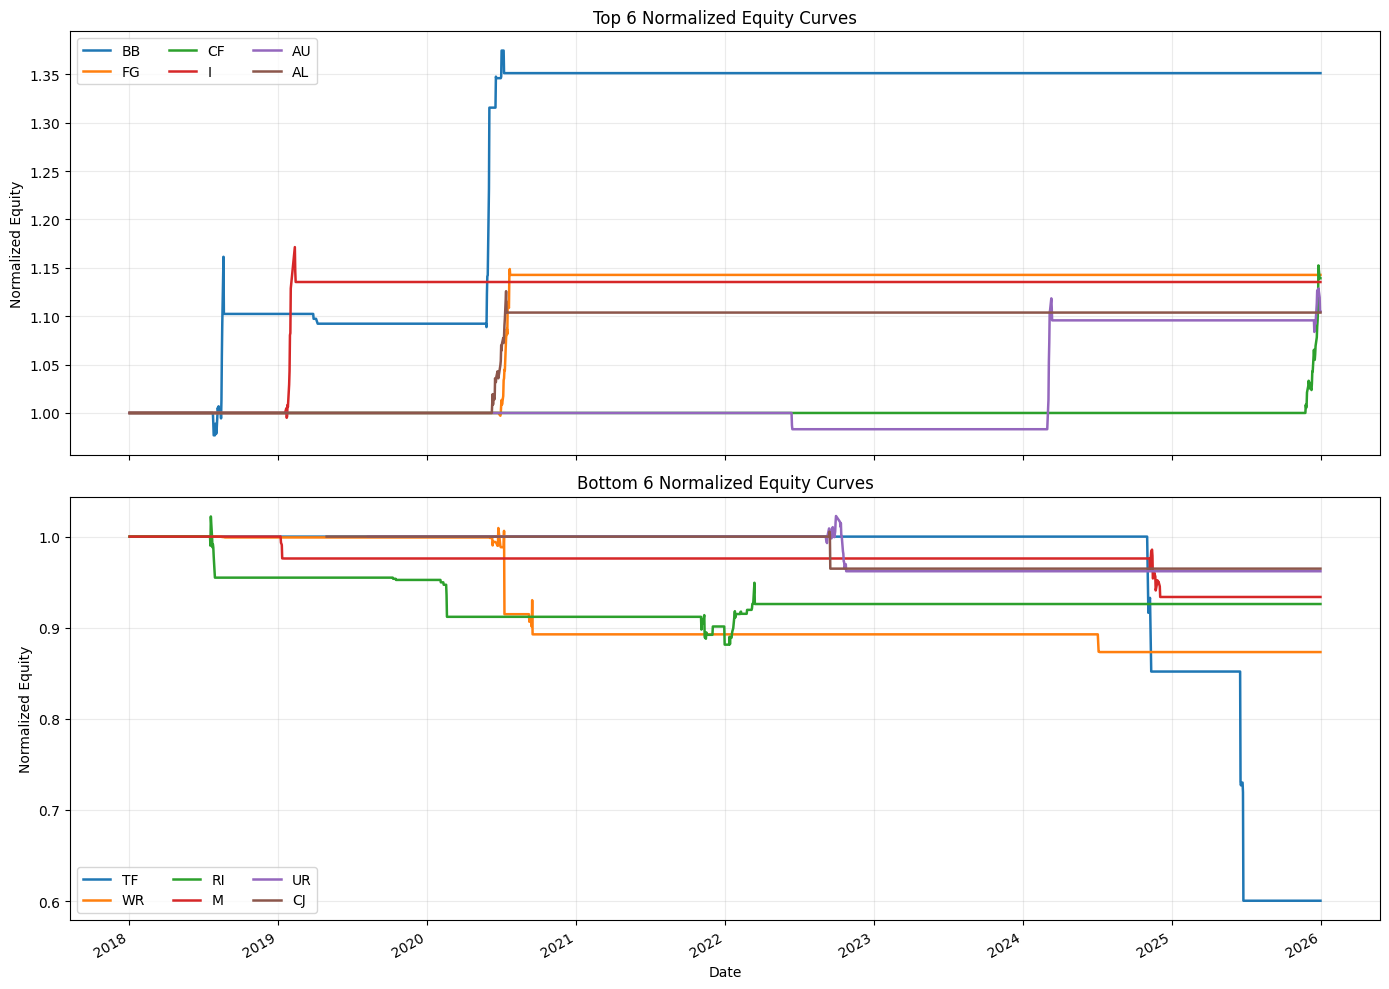

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

for symbol in top_df["symbol"]:
    curve = equity_curves[symbol].copy()
    curve["normalized_equity"] = curve["equity"] / curve["equity"].iloc[0]
    axes[0].plot(curve["date"], curve["normalized_equity"], label=symbol, linewidth=1.8)

axes[0].set_title(f"Top {top_n} Normalized Equity Curves")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Normalized Equity")
axes[0].grid(True, alpha=0.25)
axes[0].legend(ncol=3)

for symbol in bottom_df["symbol"]:
    curve = equity_curves[symbol].copy()
    curve["normalized_equity"] = curve["equity"] / curve["equity"].iloc[0]
    axes[1].plot(curve["date"], curve["normalized_equity"], label=symbol, linewidth=1.8)

axes[1].set_title(f"Bottom {bottom_n} Normalized Equity Curves")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Normalized Equity")
axes[1].grid(True, alpha=0.25)
axes[1].legend(ncol=3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

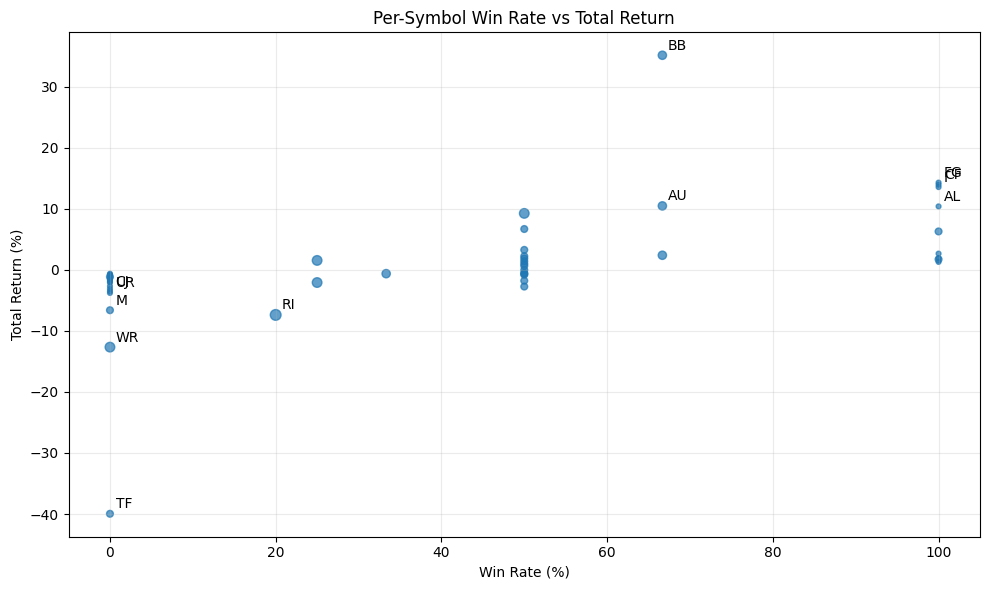

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    summary_df["win_rate_pct"],
    summary_df["total_return_pct"],
    s=summary_df["closed_trades"].clip(lower=1) * 12,
    alpha=0.7,
)

for _, row in summary_df.head(top_n).iterrows():
    ax.annotate(row["symbol"], (row["win_rate_pct"], row["total_return_pct"]), xytext=(4, 4), textcoords="offset points")
for _, row in summary_df.tail(bottom_n).iterrows():
    ax.annotate(row["symbol"], (row["win_rate_pct"], row["total_return_pct"]), xytext=(4, 4), textcoords="offset points")

ax.set_title("Per-Symbol Win Rate vs Total Return")
ax.set_xlabel("Win Rate (%)")
ax.set_ylabel("Total Return (%)")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()